# Waste Classification using Vision Transformer (ViT)

This project implements an image classification system for waste segregation using a pretrained Vision Transformer fine-tuned on the TrashNet Dataset.

The model leverages transfer learning to adapt high-level visual features learned from ImageNet to classify waste into categories such as cardboard, glass, metal, paper, plastic, and trash. A custom classification head (dense layers with dropout) is used to improve task-specific learning and reduce overfitting.

To address the limited dataset size, data augmentation techniques such as random cropping, rotation, flipping, and color jittering are applied. The model is trained using AdamW optimizer with cosine learning rate scheduling, along with stratified train-validation splitting to preserve class distribution.

Additionally, interpretability is incorporated using attention-based visualization. Attention maps are extracted from the transformer to highlight image regions influencing model predictions, enabling better understanding and trust in the model’s decisions.

The system achieves high validation accuracy (~94–96%) and demonstrates strong performance while maintaining interpretability.

In [1]:
!pip install timm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 94.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 8.3 MB/s eta 0:00:00


In [2]:
import os, torch, timm
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from torchvision.datasets import ImageFolder
from torch.optim import AdamW
from tqdm.auto import tqdm

In [3]:
DATA_ROOT = '/kaggle/input/trashnet/dataset-resized'
assert os.path.exists(DATA_ROOT), f"{DATA_ROOT} not found"

In [4]:
IMG_SIZE = 224
batch_size = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# Use ImageFolder; if dataset has a single folder named 'trashnet' with subfolders, point there:
data_dir = DATA_ROOT
dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
# split train/val
from sklearn.model_selection import StratifiedShuffleSplit
targets = [s[1] for s in dataset.samples]
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(sss.split(range(len(targets)), targets))

from torch.utils.data import Subset
train_ds = Subset(dataset, train_idx)
# val uses same folder but val_transform
val_ds_full = datasets.ImageFolder(root=data_dir, transform=val_transform)
val_ds = Subset(val_ds_full, val_idx)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

num_classes = len(dataset.classes)
print("Classes:", dataset.classes, "Num classes:", num_classes)

Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash'] Num classes: 6


In [5]:
print(len(dataset), len(train_ds), len(val_ds))
print(dataset.classes)

2527 2021 506
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [6]:
#dataset size?
print(f"Total: {len(dataset)} | Train: {len(train_ds)} | Val: {len(val_ds)}")

Total: 2527 | Train: 2021 | Val: 506


In [7]:
#images per class?

from collections import Counter

labels = [y for _, y in dataset]
counts = Counter(labels)

for i, count in counts.items():
    print(f"{dataset.classes[i]}: {count}")

cardboard: 403
glass: 501
metal: 410
paper: 594
plastic: 482
trash: 137


In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = timm.create_model('vit_base_patch16_224', pretrained=True)  # change model name if needed

# find classifier head in model and replace with custom head
def replace_head(m, hidden_dim=128, n_classes=num_classes, p_dropout=0.3):
    # various timm models expose different attributes; try common ones
    if hasattr(m, 'head') and isinstance(m.head, nn.Linear):
        in_f = m.head.in_features
        m.head = nn.Sequential(
            nn.Linear(in_f, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p_dropout),
            nn.Linear(hidden_dim, n_classes)
        )
    elif hasattr(m, 'head') and isinstance(m.head, nn.Sequential):
        # fallback: replace last linear
        last = list(m.head.children())[-1]
        if isinstance(last, nn.Linear):
            in_f = last.in_features
            m.head = nn.Sequential(
                *list(m.head.children())[:-1],
                nn.Linear(in_f, hidden_dim),
                nn.ReLU(inplace=True),
                nn.Dropout(p_dropout),
                nn.Linear(hidden_dim, n_classes)
            )
    elif hasattr(m, 'fc') and isinstance(m.fc, nn.Linear):
        in_f = m.fc.in_features
        m.fc = nn.Sequential(
            nn.Linear(in_f, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p_dropout),
            nn.Linear(hidden_dim, n_classes)
        )
    else:
        raise RuntimeError("Unknown model head - inspect model attributes (model)")

replace_head(model, hidden_dim=128, n_classes=num_classes)
model.to(device)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity(

In [9]:
#model_output_shape
imgs, _ = next(iter(train_loader))
out = model(imgs.to(device))
print(out.shape)

torch.Size([32, 6])


In [10]:
#parameter check
#Not zero → weights initialized properly
for name, param in model.named_parameters():
    print(param.mean().item())
    break

0.02392548695206642


In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay=0.01)
# optional scheduler:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

In [12]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for imgs, labels in tqdm(loader, leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    return running_loss/total, correct/total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in tqdm(loader, leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()*imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
    return running_loss/total, correct/total

In [13]:
# 1) dataset root to the folder that actually contains class subfolders
DATA_ROOT = '/kaggle/input/trashnet/dataset-resized'   

# 2) Recreate ImageFolder and check classes
from torchvision import datasets, transforms

#data augmentation
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2,0.2,0.2,0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

dataset = datasets.ImageFolder(root=DATA_ROOT, transform=train_transform)
print("Found classes:", dataset.classes)
num_classes = len(dataset.classes)
print("num_classes =", num_classes)
assert num_classes > 1, "dataset root still wrong — it must contain class subfolders"

# 3) Stratified split (recreate indices)
from sklearn.model_selection import StratifiedShuffleSplit
targets = [s[1] for s in dataset.samples]
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(sss.split(range(len(targets)), targets))

from torch.utils.data import Subset
train_ds = Subset(dataset, train_idx)

# val dataset must use val_transform (non-aug) — recreate it
val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
val_ds_full = datasets.ImageFolder(root=DATA_ROOT, transform=val_transform)
val_ds = Subset(val_ds_full, val_idx)

print("lens:", len(train_ds), len(val_ds))

# 4) Recreate loaders
from torch.utils.data import DataLoader
batch_size = 8
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

# 5) Rebuild model head with correct num_classes
import timm, torch.nn as nn, torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = timm.create_model('vit_base_patch16_224', pretrained=True)

def replace_head(m, hidden_dim=128, n_classes=num_classes, p_dropout=0.3):
    if hasattr(m, 'head') and isinstance(m.head, nn.Linear):
        in_f = m.head.in_features
        m.head = nn.Sequential(
            nn.Linear(in_f, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p_dropout),
            nn.Linear(hidden_dim, n_classes)
        )
    elif hasattr(m, 'fc') and isinstance(m.fc, nn.Linear):
        in_f = m.fc.in_features
        m.fc = nn.Sequential(
            nn.Linear(in_f, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p_dropout),
            nn.Linear(hidden_dim, n_classes)
        )
    else:
        # fallback: try replacing attribute 'head'
        try:
            in_f = m.head.in_features
            m.head = nn.Sequential(
                nn.Linear(in_f, hidden_dim),
                nn.ReLU(inplace=True),
                nn.Dropout(p_dropout),
                nn.Linear(hidden_dim, n_classes)
            )
        except Exception as e:
            raise RuntimeError("Cannot find model head to replace: " + str(e))

replace_head(model, hidden_dim=128, n_classes=num_classes)
model.to(device)


#attention weights

attn_weights = []

def get_attention(module, input, output):
    # input[0] contains qkv → we extract attention manually
    x = input[0]   # shape: (B, N, C)

    B, N, C = x.shape
    qkv = module.qkv(x)  # (B, N, 3*C)
    
    B, N, _ = qkv.shape
    
    qkv = qkv.reshape(B, N, 3, module.num_heads, -1) \
         .permute(2, 0, 3, 1, 4)
    q, k, v = qkv[0], qkv[1], qkv[2]

    attn = (q @ k.transpose(-2, -1)) * module.scale
    attn = attn.softmax(dim=-1)

    attn_weights.append(attn.detach().cpu())

# attach to LAST block
#model.blocks[-1].attn.register_forward_hook(get_attention)


# 6) Quick sanity checks
imgs, labels = next(iter(val_loader))
outs = model(imgs.to(device))
print("outs.shape:", outs.shape, "expected num_classes:", num_classes)
from collections import Counter
print("train label counts:", Counter([y for _,y in train_ds]))
print("val label counts:  ", Counter([y for _,y in val_ds]))

Found classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
num_classes = 6
lens: 2021 506
outs.shape: torch.Size([8, 6]) expected num_classes: 6
train label counts: Counter({3: 475, 1: 401, 4: 385, 2: 328, 0: 322, 5: 110})
val label counts:   Counter({3: 119, 1: 100, 4: 97, 2: 82, 0: 81, 5: 27})


In [14]:
#print(attn_weights[-1].shape)

In [15]:
imgs, labels = next(iter(train_loader))
imgs, labels = imgs.to(device), labels.to(device)

outs = model(imgs)
print(outs.shape)   # should be (batch_size, 6)
print(labels.shape) # should be (batch_size,)

torch.Size([8, 6])
torch.Size([8])


In [16]:
num_epochs = 2

# ---- Class Weights (add before criterion) ----
from collections import Counter
labels = [y for _, y in train_ds]
class_counts = Counter(labels)
num_samples = sum(class_counts.values())
class_weights = [num_samples / class_counts[i] for i in range(len(class_counts))]
class_weights = torch.tensor(class_weights).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay=0.01)

def train_epoch(model, loader):
    model.train()
    total_loss = 0.0; correct = 0; total = 0
    
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outs = model(imgs)
        loss = criterion(outs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = outs.argmax(1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

    return total_loss/total, correct/total


def validate(model, loader):
    model.eval()
    total_loss = 0.0; correct = 0; total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outs = model(imgs)
            loss = criterion(outs, labels)

            total_loss += loss.item() * imgs.size(0)
            preds = outs.argmax(1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)

    return total_loss/total, correct/total


for epoch in range(num_epochs):
    tr_loss, tr_acc = train_epoch(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)

    print(f"Epoch {epoch+1}/{num_epochs} - train_loss:{tr_loss:.4f} acc:{tr_acc:.4f} | val_loss:{val_loss:.4f} acc:{val_acc:.4f}")

# save checkpoint
torch.save(model.state_dict(), '/kaggle/working/vit_trashnet_epoch2.pth')

Epoch 1/2 - train_loss:0.7185 acc:0.7526 | val_loss:0.3442 acc:0.8834
Epoch 2/2 - train_loss:0.2927 acc:0.9095 | val_loss:0.2636 acc:0.9249


In [17]:
import os
import torch

checkpoint_path = '/kaggle/working/vit_trashnet_checkpoint.pth'
best_path       = '/kaggle/working/vit_trashnet_best.pth'

start_epoch = 0
best_val_acc = 0.0
target_total = 50

# ---- Early Stopping ----
patience = 5
counter = 0
best_val_loss = float('inf')

# ---- Resume ----
if os.path.exists(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optim_state'])
    start_epoch = ckpt.get('epoch', 0) + 1
    best_val_acc = ckpt.get('best_val_acc', 0.0)

    if 'scheduler_state' in ckpt and 'scheduler' in globals() and scheduler is not None:
        try:
            scheduler.load_state_dict(ckpt['scheduler_state'])
        except Exception:
            pass

    print(f"Resuming from checkpoint: epoch {start_epoch} (best_val_acc={best_val_acc:.4f})")
else:
    print("No checkpoint found — training from scratch")


def train_epoch(model, loader):
    model.train()
    total_loss = 0.0; correct = 0; total = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outs = model(imgs)
        loss = criterion(outs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = outs.argmax(1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

    return total_loss/total, correct/total


def validate(model, loader):
    model.eval()
    total_loss = 0.0; correct = 0; total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            outs = model(imgs)
            loss = criterion(outs, labels)

            total_loss += loss.item() * imgs.size(0)
            preds = outs.argmax(1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)

    return total_loss/total, correct/total


for epoch in range(start_epoch, target_total):

    tr_loss, tr_acc = train_epoch(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)

    # scheduler
    if 'scheduler' in globals() and scheduler is not None:
        try:
            scheduler.step()
        except Exception:
            pass

    print(f"Epoch {epoch+1}/{target_total} - train_loss:{tr_loss:.4f} acc:{tr_acc:.4f} | val_loss:{val_loss:.4f} acc:{val_acc:.4f}")

    # ---- Early Stopping ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

    # ---- Save Best ----
    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict() if ('scheduler' in globals() and scheduler is not None) else None,
            'best_val_acc': best_val_acc
        }, best_path)

        print(f"  -> Best model updated (val_acc={best_val_acc:.4f}) saved to {best_path}")

    # ---- Checkpoint ----
    if ((epoch + 1) % 10 == 0) or (epoch + 1 == target_total):
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict() if ('scheduler' in globals() and scheduler is not None) else None,
            'best_val_acc': best_val_acc
        }, checkpoint_path)

        print(f"  -> Checkpoint saved to {checkpoint_path} (epoch {epoch+1})")

No checkpoint found — training from scratch


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 1/50 - train_loss:0.2022 acc:0.9411 | val_loss:0.1902 acc:0.9289
  -> Best model updated (val_acc=0.9289) saved to /kaggle/working/vit_trashnet_best.pth
Epoch 2/50 - train_loss:0.1309 acc:0.9594 | val_loss:0.2663 acc:0.9071
Epoch 3/50 - train_loss:0.1657 acc:0.9471 | val_loss:0.1897 acc:0.9289
Epoch 4/50 - train_loss:0.0875 acc:0.9753 | val_loss:0.2879 acc:0.9170
Epoch 5/50 - train_loss:0.1009 acc:0.9683 | val_loss:0.2647 acc:0.9229
Epoch 6/50 - train_loss:0.1018 acc:0.9718 | val_loss:0.2836 acc:0.9269
Epoch 7/50 - train_loss:0.0675 acc:0.9777 | val_loss:0.2614 acc:0.9170
Epoch 8/50 - train_loss:0.0732 acc:0.9812 | val_loss:0.3776 acc:0.8597
Early stopping triggered


In [18]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu()

        y_true.extend(labels.numpy())
        y_pred.extend(preds.numpy())

print(classification_report(y_true, y_pred, target_names=dataset.classes))

              precision    recall  f1-score   support

   cardboard       0.94      0.96      0.95        81
       glass       0.98      0.64      0.78       100
       metal       0.89      0.94      0.91        82
       paper       0.98      0.86      0.91       119
     plastic       0.69      0.96      0.81        97
       trash       0.64      0.78      0.70        27

    accuracy                           0.86       506
   macro avg       0.85      0.86      0.84       506
weighted avg       0.89      0.86      0.86       506



<Axes: >

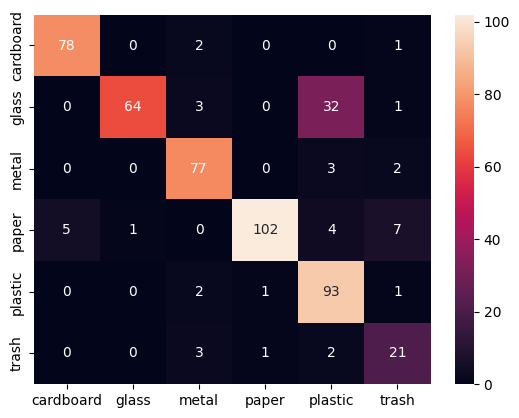

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=dataset.classes,
            yticklabels=dataset.classes)

In [20]:
# ===== LOAD BEST MODEL FOR VISUALIZATION =====
best_path = '/kaggle/working/vit_trashnet_best.pth'

if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    print("Loaded best model for visualization")
else:
    print("Best model not found, using current model")

model.eval()


Loaded best model for visualization


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity(

In [21]:
attn_weights = []

model.blocks[-1].attn.register_forward_hook(get_attention)
def visualize_attention(img, model):
    model.eval()
    attn_weights.clear()

    with torch.no_grad():
        _ = model(img.unsqueeze(0).to(device))

    if len(attn_weights) == 0:
        print("❌ No attention captured")
        return None

    attn = attn_weights[-1][0]   # (heads, tokens, tokens)
    attn = attn.mean(0)          # avg heads → (tokens, tokens)

    cls_attn = attn[0, 1:]       # CLS → patches
    size = int(np.sqrt(len(cls_attn)))

    heatmap = cls_attn.reshape(size, size).numpy()

    plt.imshow(heatmap, cmap='jet')
    plt.title("Attention Map")
    plt.colorbar()
    plt.show()

    return heatmap

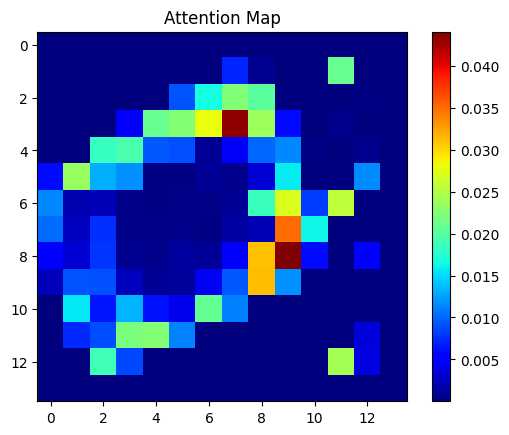

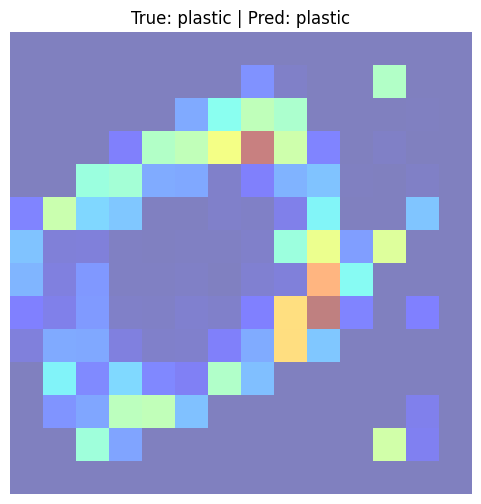

In [22]:
import numpy as np
import matplotlib.pyplot as plt
img, label = val_ds[0]

# ---- Get prediction ----
model.eval()
with torch.no_grad():
    out = model(img.unsqueeze(0).to(device))
    pred = out.argmax(dim=1).item()

true_label = dataset.classes[label]
pred_label = dataset.classes[pred]

# ---- Get attention ----
heatmap = visualize_attention(img, model)

# ---- Plot ----
if heatmap is not None:
    plt.figure(figsize=(6,6))
    
    plt.imshow(img.permute(1,2,0).cpu())
    plt.imshow(heatmap, cmap='jet', alpha=0.5)
    
    plt.title(f"True: {true_label} | Pred: {pred_label}")
    plt.axis('off')
    
    plt.show()

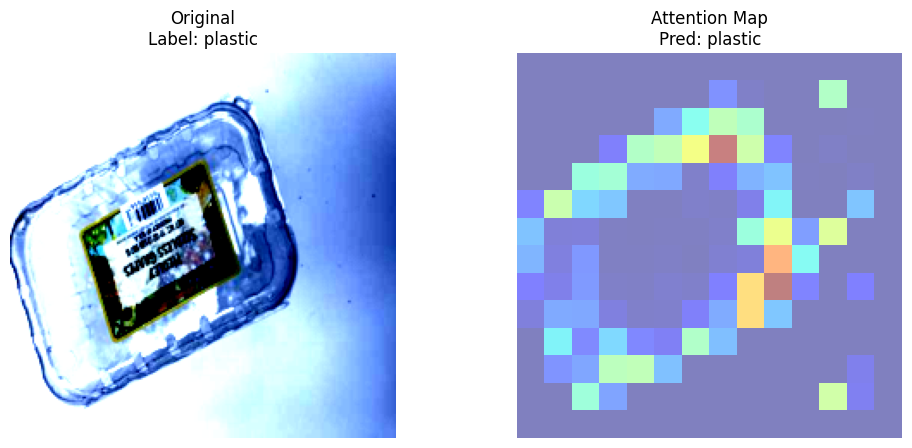

In [23]:
plt.figure(figsize=(12,5))

# Original image
plt.subplot(1,2,1)
plt.imshow(img.permute(1,2,0).cpu())
plt.title(f"Original\nLabel: {true_label}")
plt.axis('off')

# Attention overlay
plt.subplot(1,2,2)
plt.imshow(img.permute(1,2,0).cpu())
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.title(f"Attention Map\nPred: {pred_label}")
plt.axis('off')

plt.show()

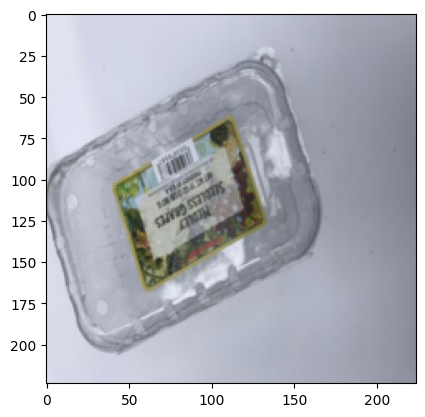

In [24]:
def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return img * std + mean

plt.imshow(denormalize(img).permute(1,2,0))

In [25]:
#visualisation
def get_classes(dataset):
    if hasattr(dataset, 'classes'):
        return dataset.classes
    elif hasattr(dataset, 'dataset'):
        return dataset.dataset.classes
    else:
        raise ValueError("Classes not found")


def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (img * std + mean).clamp(0,1)


def visualize_batch(model, dataset, num_samples=6):
    model.eval()
    classes = get_classes(dataset)

    import random
    indices = random.sample(range(len(dataset)), num_samples)

    # 2 rows: original + attention
    plt.figure(figsize=(3*num_samples, 6))

    for i, idx in enumerate(indices):
        img, label = dataset[idx]

        # ---- prediction ----
        with torch.no_grad():
            out = model(img.unsqueeze(0).to(device))
            pred = out.argmax(dim=1).item()

        true_label = classes[label]
        pred_label = classes[pred]

        # ---- attention ----
        heatmap = visualize_attention(img, model)

        # ---- denormalize image ----
        img_disp = denormalize(img).permute(1,2,0).cpu()

        # ===== TOP ROW: ORIGINAL =====
        plt.subplot(2, num_samples, i+1)
        plt.imshow(img_disp)
        plt.title(f"True: {true_label}", fontsize=10)
        plt.axis('off')

        # ===== BOTTOM ROW: ATTENTION =====
        plt.subplot(2, num_samples, i+1+num_samples)

        if heatmap is not None:
            plt.imshow(img_disp)
            plt.imshow(heatmap, cmap='jet', alpha=0.5)
        else:
            plt.imshow(img_disp)

        color = "green" if true_label == pred_label else "red"
        plt.title(f"Pred: {pred_label}", color=color, fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

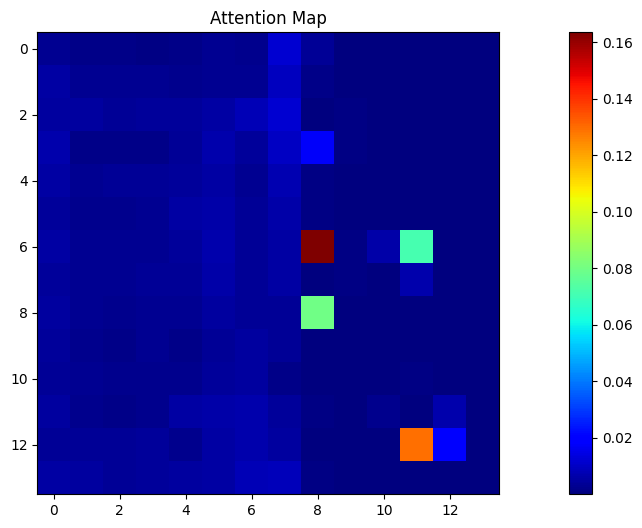

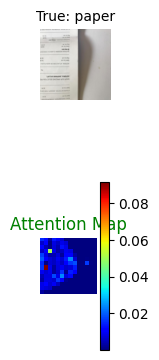

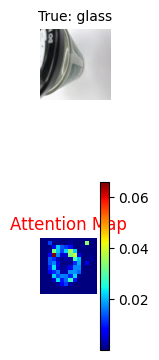

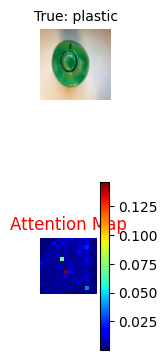

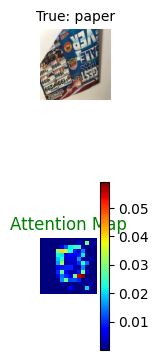

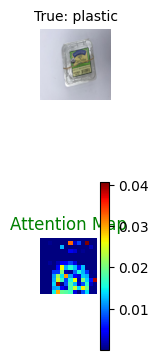

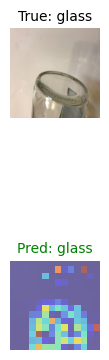

In [26]:
visualize_batch(model, val_ds, num_samples=6)

In [27]:
print(y_pred[:20])

[4, 2, 2, 0, 1, 1, 3, 5, 4, 2, 4, 0, 3, 0, 0, 3, 4, 4, 3, 2]


In [28]:
print([dataset.classes[i] for i in y_pred[:10]])

['plastic', 'metal', 'metal', 'cardboard', 'glass', 'glass', 'paper', 'trash', 'plastic', 'metal']
